# What Makes a Movie Oscar-Worthy?
## DSA210 — Spring 2026 | EDA & Hypothesis Testing

This notebook covers:
1. Data loading and merging
2. Data cleaning
3. Exploratory Data Analysis (EDA)
4. Hypothesis Testing


In [10]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import json
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12


## 1. Data Loading & Merging

In [12]:
movies = pd.read_csv('/content/drive/MyDrive/tmdb_5000_movies.csv')
print(f"TMDB Movies: {movies.shape[0]} rows, {movies.shape[1]} columns")
print(f"Columns: {movies.columns.tolist()}")
movies.head()


TMDB Movies: 4803 rows, 20 columns
Columns: ['budget', 'genres', 'homepage', 'id', 'keywords', 'original_language', 'original_title', 'overview', 'popularity', 'production_companies', 'production_countries', 'release_date', 'revenue', 'runtime', 'spoken_languages', 'status', 'tagline', 'title', 'vote_average', 'vote_count']


,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",2015-10-26,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-07-16,1084939099,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-03-07,284139100,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124


In [13]:
oscar = pd.read_csv('/content/drive/MyDrive/the_oscar_award.csv')
print(f"Oscar Data: {oscar.shape[0]} rows, {oscar.shape[1]} columns")
print(f"Columns: {oscar.columns.tolist()}")
oscar.head()


Oscar Data: 11110 rows, 8 columns
Columns: ['year_film', 'year_ceremony', 'ceremony', 'category', 'canon_category', 'name', 'film', 'winner']


,year_film,year_ceremony,ceremony,category,canon_category,name,film,winner
0,1927,1928,1,ACTOR,ACTOR IN A LEADING ROLE,Richard Barthelmess,The Noose,False
1,1927,1928,1,ACTOR,ACTOR IN A LEADING ROLE,Richard Barthelmess,The Patent Leather Kid,False
2,1927,1928,1,ACTOR,ACTOR IN A LEADING ROLE,Emil Jannings,The Last Command,True
3,1927,1928,1,ACTOR,ACTOR IN A LEADING ROLE,Emil Jannings,The Way of All Flesh,True
4,1927,1928,1,ACTRESS,ACTRESS IN A LEADING ROLE,Louise Dresser,A Ship Comes In,False


### Merging the Datasets
We match movies by title (case-insensitive) to create:
- `nominated`: binary label (1 = at least one Oscar nomination)
- `nomination_count`: total nominations across all categories
- `winner`: whether the film won at least one Oscar


In [14]:
oscar['film_lower'] = oscar['film'].dropna().str.strip().str.lower()

nom_counts = oscar.groupby('film_lower').agg(
    nomination_count=('film_lower', 'size'),
    winner=('winner', lambda x: x.any())
).reset_index()

movies['title_lower'] = movies['title'].str.strip().str.lower()

df = movies.merge(nom_counts, left_on='title_lower', right_on='film_lower', how='left')
df['nominated'] = df['nomination_count'].notna().astype(int)
df['nomination_count'] = df['nomination_count'].fillna(0).astype(int)
df['winner'] = df['winner'].fillna(False)

print(f"Total movies: {len(df)}")
print(f"Nominated: {df['nominated'].sum()} ({df['nominated'].mean()*100:.1f}%)")
print(f"Not nominated: {(df['nominated']==0).sum()} ({(df['nominated']==0).mean()*100:.1f}%)")
print(f"Winners: {df['winner'].sum()}")


Total movies: 4803
Nominated: 985 (20.5%)
Not nominated: 3818 (79.5%)
Winners: 387


## 2. Data Cleaning

In [15]:
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df['release_year'] = df['release_date'].dt.year
df['release_month'] = df['release_date'].dt.month

def extract_genres(genre_json):
    try:
        genres = json.loads(genre_json)
        return [g['name'] for g in genres]
    except:
        return []

df['genre_list'] = df['genres'].apply(extract_genres)
df['primary_genre'] = df['genre_list'].apply(lambda x: x[0] if len(x) > 0 else 'Unknown')

print(f"Movies with budget = 0: {(df['budget']==0).sum()}")
print(f"Movies with runtime = 0 or NaN: {(df['runtime'].isna() | (df['runtime']==0)).sum()}")

df['has_budget'] = (df['budget'] > 0).astype(int)
df['has_revenue'] = (df['revenue'] > 0).astype(int)

df['q4_release'] = df['release_month'].isin([10, 11, 12]).astype(int)

print(f"\nCleaned dataset shape: {df.shape}")
df[['title', 'budget', 'revenue', 'runtime', 'vote_average', 'release_year', 'release_month', 'primary_genre', 'nominated', 'nomination_count']].head(10)


Movies with budget = 0: 1037
Movies with runtime = 0 or NaN: 37

Cleaned dataset shape: (4803, 32)


,title,budget,revenue,runtime,vote_average,release_year,release_month,primary_genre,nominated,nomination_count
0,Avatar,237000000,2787965087,162.0,7.2,2009.0,12.0,Action,1,9
1,Pirates of the Caribbean: At World's End,300000000,961000000,169.0,6.9,2007.0,5.0,Adventure,1,2
2,Spectre,245000000,880674609,148.0,6.3,2015.0,10.0,Action,1,1
3,The Dark Knight Rises,250000000,1084939099,165.0,7.6,2012.0,7.0,Action,0,0
4,John Carter,260000000,284139100,132.0,6.1,2012.0,3.0,Action,0,0
5,Spider-Man 3,258000000,890871626,139.0,5.9,2007.0,5.0,Fantasy,0,0
6,Tangled,260000000,591794936,100.0,7.4,2010.0,11.0,Animation,1,1
7,Avengers: Age of Ultron,280000000,1405403694,141.0,7.3,2015.0,4.0,Action,0,0
8,Harry Potter and the Half-Blood Prince,250000000,933959197,153.0,7.4,2009.0,7.0,Adventure,1,1
9,Batman v Superman: Dawn of Justice,250000000,873260194,151.0,5.7,2016.0,3.0,Action,0,0


## 3. Exploratory Data Analysis

### 3.1 Summary Statistics: Nominated vs. Non-Nominated

In [16]:
comparison_cols = ['budget', 'revenue', 'runtime', 'vote_average', 'vote_count', 'popularity']
comparison = df.groupby('nominated')[comparison_cols].mean().T
comparison.columns = ['Not Nominated', 'Nominated']
comparison['Difference'] = comparison['Nominated'] - comparison['Not Nominated']
comparison['% Difference'] = (comparison['Difference'] / comparison['Not Nominated'] * 100).round(1)
comparison.round(2)


,Not Nominated,Nominated,Difference,% Difference
budget,25966357.11,4.097845e+07,1.501209e+07,57.8
revenue,61383469.73,1.631835e+08,1.018000e+08,165.8
runtime,103.06,1.216500e+02,1.858000e+01,18.0
vote_average,5.88,6.920000e+00,1.050000e+00,17.8
vote_count,514.72,1.370460e+03,8.557400e+02,166.3
popularity,17.82,3.573000e+01,1.791000e+01,100.5


### 3.2 Budget Distribution

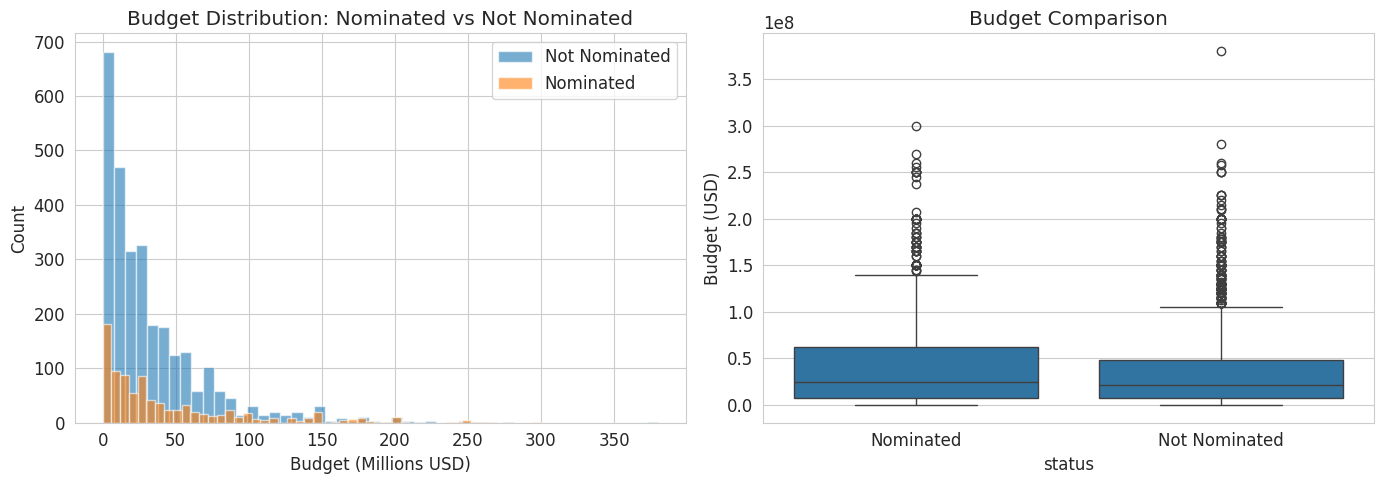

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
budget_df = df[df['budget'] > 0].copy()

for label, group in budget_df.groupby('nominated'):
    tag = 'Nominated' if label == 1 else 'Not Nominated'
    axes[0].hist(group['budget'] / 1e6, bins=50, alpha=0.6, label=tag)
axes[0].set_xlabel('Budget (Millions USD)')
axes[0].set_ylabel('Count')
axes[0].set_title('Budget Distribution: Nominated vs Not Nominated')
axes[0].legend()

budget_df['status'] = budget_df['nominated'].map({1: 'Nominated', 0: 'Not Nominated'})
sns.boxplot(data=budget_df, x='status', y='budget', ax=axes[1])
axes[1].set_ylabel('Budget (USD)')
axes[1].set_title('Budget Comparison')

plt.tight_layout()
plt.show()


### 3.3 Runtime Distribution

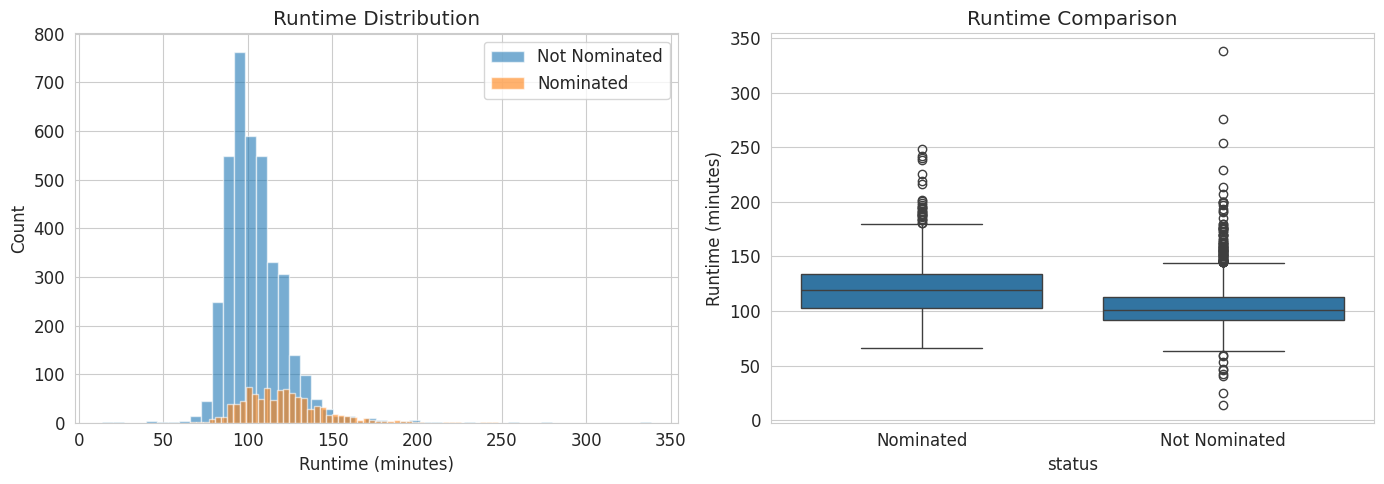

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

runtime_df = df[df['runtime'] > 0].copy()

for label, group in runtime_df.groupby('nominated'):
    tag = 'Nominated' if label == 1 else 'Not Nominated'
    axes[0].hist(group['runtime'], bins=50, alpha=0.6, label=tag)
axes[0].set_xlabel('Runtime (minutes)')
axes[0].set_ylabel('Count')
axes[0].set_title('Runtime Distribution')
axes[0].legend()

runtime_df['status'] = runtime_df['nominated'].map({1: 'Nominated', 0: 'Not Nominated'})
sns.boxplot(data=runtime_df, x='status', y='runtime', ax=axes[1])
axes[1].set_ylabel('Runtime (minutes)')
axes[1].set_title('Runtime Comparison')

plt.tight_layout()
plt.show()


### 3.4 Audience Ratings (Vote Average)

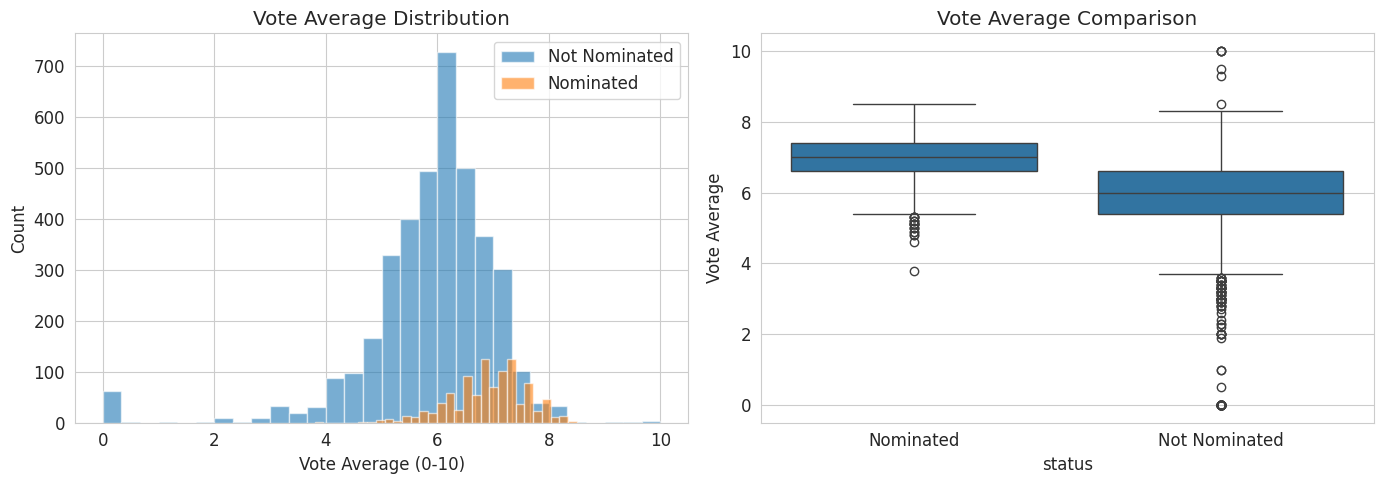

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for label, group in df.groupby('nominated'):
    tag = 'Nominated' if label == 1 else 'Not Nominated'
    axes[0].hist(group['vote_average'], bins=30, alpha=0.6, label=tag)
axes[0].set_xlabel('Vote Average (0-10)')
axes[0].set_ylabel('Count')
axes[0].set_title('Vote Average Distribution')
axes[0].legend()

df['status'] = df['nominated'].map({1: 'Nominated', 0: 'Not Nominated'})
sns.boxplot(data=df, x='status', y='vote_average', ax=axes[1])
axes[1].set_ylabel('Vote Average')
axes[1].set_title('Vote Average Comparison')

plt.tight_layout()
plt.show()


### 3.5 Release Month — Does 'Oscar Season' Exist?

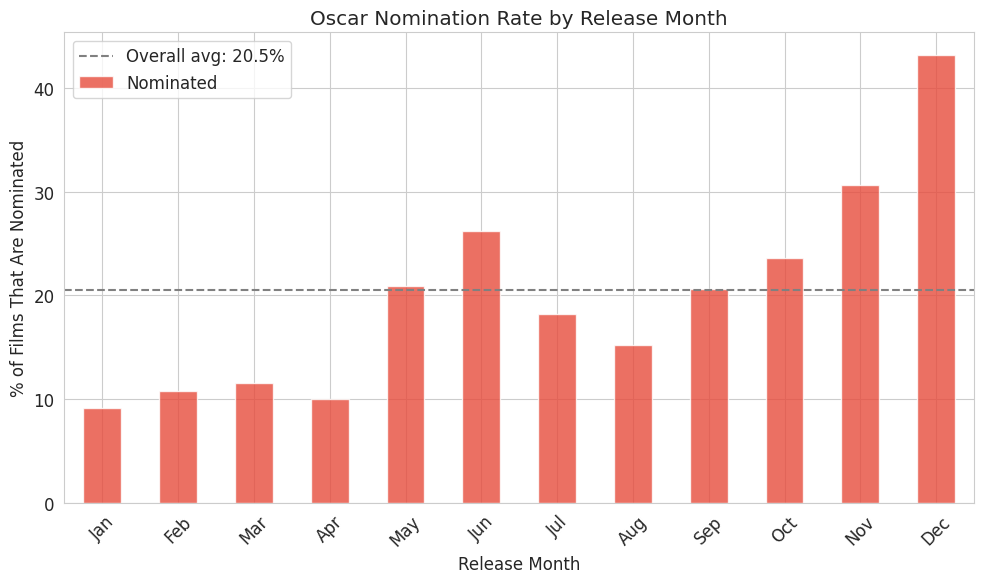

In [20]:
fig, ax = plt.subplots(figsize=(10, 6))

month_data = df.groupby(['release_month', 'nominated']).size().unstack(fill_value=0)
month_data.columns = ['Not Nominated', 'Nominated']
month_pct = month_data.div(month_data.sum(axis=1), axis=0) * 100

month_pct['Nominated'].plot(kind='bar', ax=ax, color='#e74c3c', alpha=0.8)
ax.set_xlabel('Release Month')
ax.set_ylabel('% of Films That Are Nominated')
ax.set_title('Oscar Nomination Rate by Release Month')
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'], rotation=45)
ax.axhline(y=df['nominated'].mean()*100, color='gray', linestyle='--', label=f'Overall avg: {df["nominated"].mean()*100:.1f}%')
ax.legend()

plt.tight_layout()
plt.show()


### 3.6 Genre Analysis

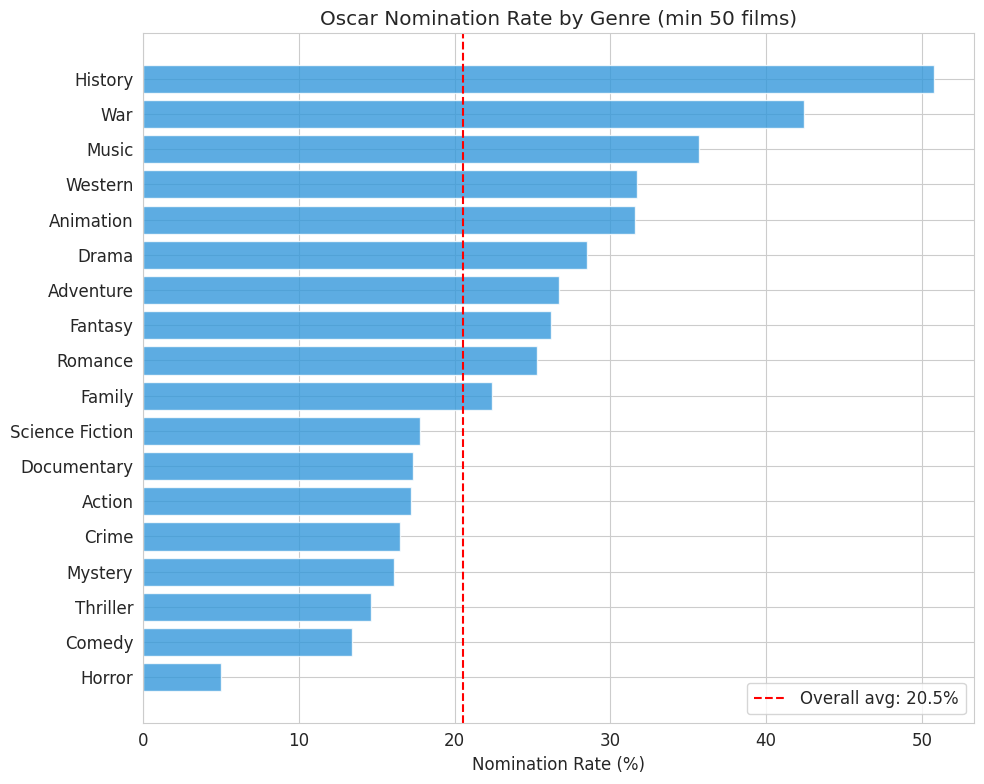

In [21]:
genre_exploded = df.explode('genre_list')
genre_exploded = genre_exploded[genre_exploded['genre_list'].notna()]

genre_stats = genre_exploded.groupby('genre_list').agg(
    total=('nominated', 'count'),
    nominated=('nominated', 'sum')
).reset_index()
genre_stats['nomination_rate'] = (genre_stats['nominated'] / genre_stats['total'] * 100).round(1)
genre_stats = genre_stats[genre_stats['total'] >= 50].sort_values('nomination_rate', ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(genre_stats['genre_list'], genre_stats['nomination_rate'], color='#3498db', alpha=0.8)
ax.set_xlabel('Nomination Rate (%)')
ax.set_title('Oscar Nomination Rate by Genre (min 50 films)')
ax.axvline(x=df['nominated'].mean()*100, color='red', linestyle='--', label=f'Overall avg: {df["nominated"].mean()*100:.1f}%')
ax.legend()

plt.tight_layout()
plt.show()


### 3.7 Correlation Heatmap

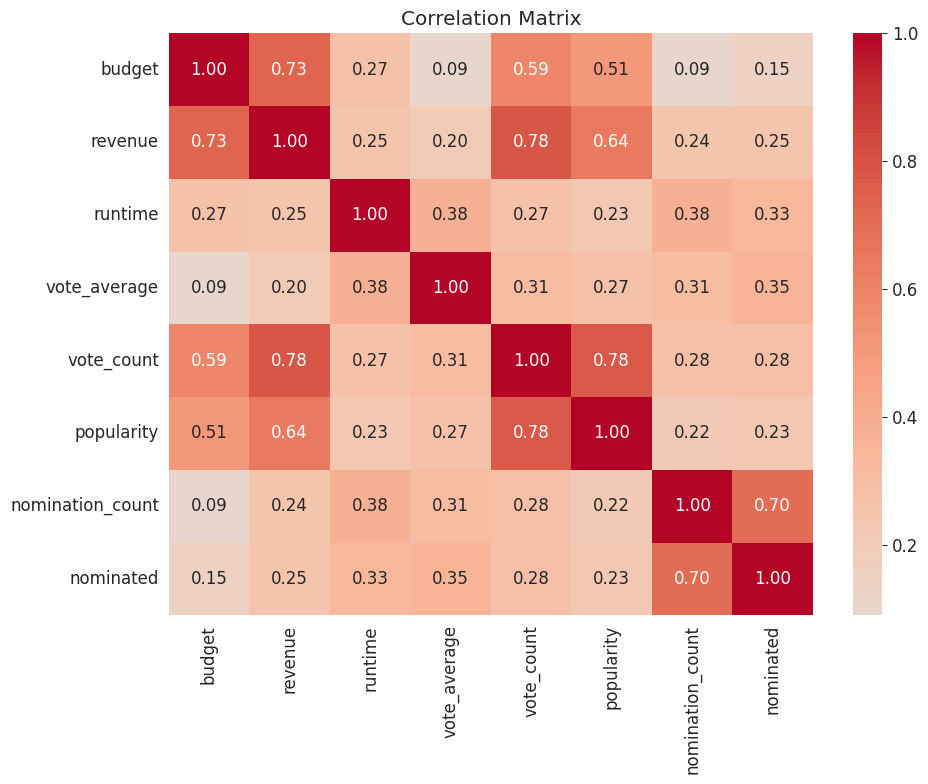

In [22]:
corr_cols = ['budget', 'revenue', 'runtime', 'vote_average', 'vote_count', 'popularity', 'nomination_count', 'nominated']
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f', ax=ax)
ax.set_title('Correlation Matrix')

plt.tight_layout()
plt.show()


## 4. Hypothesis Testing

We test whether the observed differences between nominated and non-nominated films are statistically significant.


### Test 1: Budget
**H₀:** There is no significant difference in budget between nominated and non-nominated films.  
**H₁:** Oscar-nominated films have significantly higher budgets.


In [23]:
budget_df = df[df['budget'] > 0]
nom_budget = budget_df[budget_df['nominated'] == 1]['budget']
non_budget = budget_df[budget_df['nominated'] == 0]['budget']

stat, p = stats.mannwhitneyu(nom_budget, non_budget, alternative='greater')
print(f"Nominated mean budget: ${nom_budget.mean():,.0f}")
print(f"Non-nominated mean budget: ${non_budget.mean():,.0f}")
print(f"Mann-Whitney U statistic: {stat:,.0f}")
print(f"P-value: {p:.2e}")
print(f"Result: {'Reject H0 — significant difference' if p < 0.05 else 'Fail to reject H0'}")


Nominated mean budget: $45,403,572
Non-nominated mean budget: $34,459,351
Mann-Whitney U statistic: 1,385,707
P-value: 8.08e-05
Result: Reject H0 — significant difference


### Test 2: Runtime
**H₀:** There is no significant difference in runtime between nominated and non-nominated films.  
**H₁:** Oscar-nominated films have significantly longer runtimes.


In [24]:
runtime_df = df[df['runtime'] > 0]
nom_runtime = runtime_df[runtime_df['nominated'] == 1]['runtime']
non_runtime = runtime_df[runtime_df['nominated'] == 0]['runtime']

stat, p = stats.mannwhitneyu(nom_runtime, non_runtime, alternative='greater')
print(f"Nominated mean runtime: {nom_runtime.mean():.1f} min")
print(f"Non-nominated mean runtime: {non_runtime.mean():.1f} min")
print(f"Mann-Whitney U statistic: {stat:,.0f}")
print(f"P-value: {p:.2e}")
print(f"Result: {'Reject H0 — significant difference' if p < 0.05 else 'Fail to reject H0'}")


Nominated mean runtime: 121.6 min
Non-nominated mean runtime: 104.0 min
Mann-Whitney U statistic: 2,730,770
P-value: 2.89e-113
Result: Reject H0 — significant difference


### Test 3: Vote Average (Audience Rating)
**H₀:** There is no significant difference in audience ratings between nominated and non-nominated films.  
**H₁:** Oscar-nominated films have significantly higher ratings.


In [25]:
nom_votes = df[df['nominated'] == 1]['vote_average']
non_votes = df[df['nominated'] == 0]['vote_average']

stat, p = stats.mannwhitneyu(nom_votes, non_votes, alternative='greater')
print(f"Nominated mean vote average: {nom_votes.mean():.2f}")
print(f"Non-nominated mean vote average: {non_votes.mean():.2f}")
print(f"Mann-Whitney U statistic: {stat:,.0f}")
print(f"P-value: {p:.2e}")
print(f"Result: {'Reject H0 — significant difference' if p < 0.05 else 'Fail to reject H0'}")


Nominated mean vote average: 6.92
Non-nominated mean vote average: 5.88
Mann-Whitney U statistic: 3,040,844
P-value: 4.68e-197
Result: Reject H0 — significant difference


### Test 4: Q4 Release ("Oscar Season")
**H₀:** The proportion of Q4 releases is the same for nominated and non-nominated films.  
**H₁:** Oscar-nominated films are more likely to be released in Q4 (Oct–Dec).


In [26]:
contingency = pd.crosstab(df['nominated'], df['q4_release'])
print("Contingency table:")
print(contingency)
print()

chi2, p, dof, expected = stats.chi2_contingency(contingency)
q4_nom = df[df['nominated']==1]['q4_release'].mean() * 100
q4_non = df[df['nominated']==0]['q4_release'].mean() * 100
print(f"Q4 release rate — Nominated: {q4_nom:.1f}%, Non-nominated: {q4_non:.1f}%")
print(f"Chi-square statistic: {chi2:.2f}")
print(f"P-value: {p:.2e}")
print(f"Result: {'Reject H0 — significant difference' if p < 0.05 else 'Fail to reject H0'}")


Contingency table:
q4_release     0    1
nominated            
0           2971  847
1            576  409

Q4 release rate — Nominated: 41.5%, Non-nominated: 22.2%
Chi-square statistic: 150.63
P-value: 1.26e-34
Result: Reject H0 — significant difference


## 5. Summary of Findings

| Test | Feature | Nominated Mean | Non-Nominated Mean | P-value | Result |
|------|---------|---------------|-------------------|---------|--------|
| 1 | Budget | $45.4M | $34.5M | 8.08e-05 | Reject H0 |
| 2 | Runtime | 121.6 min | 104.0 min | 2.89e-113 | Reject H0 |
| 3 | Vote Average | 6.92 | 5.88 | 4.68e-197 | Reject H0 |
| 4 | Q4 Release | 41.5% | 22.2% | 1.26e-34 | Reject H0 |

All four hypotheses show statistically significant differences between Oscar nominated and non-nominated films. Nominated films tend to have higher budgets, longer runtimes, better audience ratings, and are nearly twice as likely to be released in the October–December window.


